C:\Users\steff\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Device set to use cpu



Month 1
Total Savings Before Expenses: $10000.00
Generated Data:
                         Date       Description  Amount        Category
0  2025-01-10 01:52:13.503150            Target  473.23        Shopping
1  2025-01-10 01:52:13.503150         Starbucks   96.44          Dining
2  2025-01-10 01:52:13.503150      CVS Pharmacy  743.49      Healthcare
3  2025-01-12 01:52:13.503150            Target   73.40        Shopping
4  2025-01-12 01:52:13.503150           Netflix   44.08   Entertainment
5  2025-01-12 01:52:13.503150           Netflix   50.53   Entertainment
6  2025-01-12 01:52:13.503150           Netflix   33.90   Entertainment
7  2025-01-12 01:52:13.503150            Target  209.82        Shopping
8  2025-01-12 01:52:13.503150  Electric Company   77.22       Utilities
9  2025-01-15 01:52:13.503150              Uber   74.95  Transportation
10 2025-01-16 01:52:13.503150           Spotify   17.70   Entertainment
11 2025-01-17 01:52:13.503150  Electric Company  173.48       Utilitie

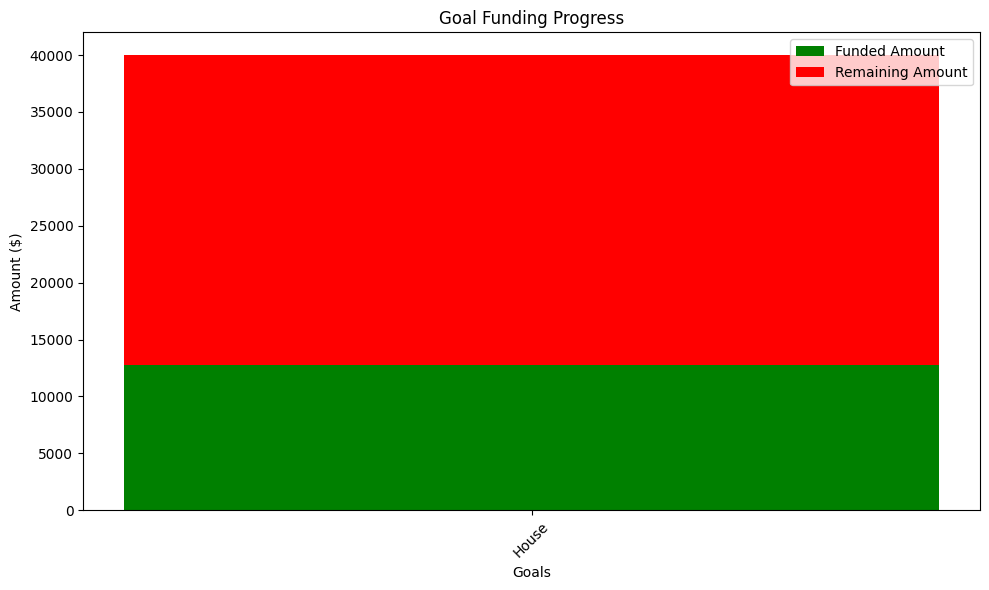

Months left to pay off the house: 18.18


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline as hf_pipeline
from datetime import datetime, timedelta
import random
import torch
from concurrent.futures import ThreadPoolExecutor
import concurrent.futures
from IPython.display import Image, display

class TransactionDataGenerator:
    def __init__(self):
        self.categories = {
            'Groceries': {'merchants': ['Walmart', 'Whole Foods'], 'amount_range': (10, 300)},
            'Dining': {'merchants': ['McDonald\'s', 'Starbucks'], 'amount_range': (5, 100)},
            'Transportation': {'merchants': ['Uber', 'Lyft'], 'amount_range': (5, 150)},
            'Shopping': {'merchants': ['Amazon', 'Target'], 'amount_range': (10, 500)},
            'Entertainment': {'merchants': ['Netflix', 'Spotify'], 'amount_range': (5, 80)},
            'Utilities': {'merchants': ['Electric Company', 'Water Utility'], 'amount_range': (30, 300)},
            'Healthcare': {'merchants': ['CVS Pharmacy', 'Walgreens'], 'amount_range': (10, 1000)}
        }

    def generate_date_range(self, start_date, num_days):
        return [start_date + timedelta(days=x) for x in range(num_days)]

    def generate_transaction(self, date):
        category = random.choice(list(self.categories.keys()))
        merchant_info = self.categories[category]
        merchant = random.choice(merchant_info['merchants'])
        amount = round(random.uniform(*merchant_info['amount_range']), 2)
        return {'Date': date, 'Description': merchant, 'Amount': amount, 'Category': category}

    def generate_dataset(self, num_transactions):
        start_date = datetime.now() - timedelta(days=30)
        date_range = self.generate_date_range(start_date, 30)
        transactions = [self.generate_transaction(random.choice(date_range)) for _ in range(min(num_transactions, 50))]
        return pd.DataFrame(transactions).sort_values('Date').reset_index(drop=True)

class TransactionCategorizer:
    def __init__(self):
        self.classifier = hf_pipeline("zero-shot-classification", model="facebook/bart-large-mnli", device=0)
        self.candidate_labels = ['Groceries', 'Dining', 'Transportation', 'Shopping', 'Entertainment', 'Utilities', 'Healthcare']

    def categorize_batch(self, batch):
        batch_results = self.classifier(batch, self.candidate_labels)
        return [res['labels'][0] for res in batch_results]

    def categorize(self, data):
        descriptions = data['Description'].fillna('').tolist()
        results = []
        batch_size = 16  # Adjust the batch size as needed
        with concurrent.futures.ThreadPoolExecutor() as executor:
            futures = [executor.submit(self.categorize_batch, descriptions[i:i + batch_size]) for i in range(0, len(descriptions), batch_size)]
            for future in concurrent.futures.as_completed(futures):
                results.extend(future.result())
        data['Predicted_Category'] = results
        return data

class SpendingRecommender:
    def __init__(self, state_tier):
        self.state_tier = state_tier
        self.categories = self._set_category_percentages()

    def _set_category_percentages(self):
        tier_adjustments = {
            'Tier 1': {'Groceries': 12, 'Dining': 5, 'Transportation': 15, 'Utilities': 10, 'Healthcare': 10, 'Entertainment': 5, 'Shopping': 5},
            'Tier 2': {'Groceries': 15, 'Dining': 5, 'Transportation': 15, 'Utilities': 10, 'Healthcare': 10, 'Entertainment': 5, 'Shopping': 5},
            'Tier 3': {'Groceries': 20, 'Dining': 5, 'Transportation': 15, 'Utilities': 10, 'Healthcare': 10, 'Entertainment': 5, 'Shopping': 5}
        }
        return tier_adjustments[self.state_tier]

    def get_recommendation_data(self, category_spending, total_spent):
        return {category: round(total_spent * (percent / 100), 2) for category, percent in self.categories.items()}

class GoalPlanner:
    def __init__(self, total_savings):
        self.total_savings = total_savings
        self.goals = []

    def add_goal(self, name, amount, monthly_payment):
        months = amount / monthly_payment
        self.goals.append({'name': name, 'amount': amount, 'months': months, 'remaining_amount': amount, 'monthly_payment': monthly_payment})

    def plan_goals(self):
        for goal in sorted(self.goals, key=lambda x: x['months']):
            if goal['amount'] > 0 and goal['months'] > 0:
                monthly_contribution = goal['monthly_payment']
                contribution = monthly_contribution
                goal['amount'] -= contribution
                goal['months'] = goal['amount'] / monthly_contribution
        return {goal['name']: f"Remaining: ${goal['amount']:.2f}, Months Left: {goal['months']}" for goal in self.goals}

    def calculate_months_left(self, goal):
        total_remaining = goal['remaining_amount']
        monthly_payment = goal['monthly_payment']
        months_left = total_remaining / monthly_payment
        return months_left

    def visualize_goals(self):
        labels = [goal['name'] for goal in self.goals]
        remaining_amounts = [goal['remaining_amount'] for goal in self.goals]
        funded_amounts = [goal['amount'] - goal['remaining_amount'] for goal in self.goals]
        plt.figure(figsize=(10, 6))
        plt.bar(labels, funded_amounts, color='green', label='Funded Amount')
        plt.bar(labels, remaining_amounts, bottom=funded_amounts, color='red', label='Remaining Amount')
        plt.xlabel('Goals')
        plt.ylabel('Amount ($)')
        plt.title('Goal Funding Progress')
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.savefig('goal_funding_progress.png')
        plt.close()
        display(Image(filename='goal_funding_progress.png'))

    def visualize_goal_funding(self, goal, additional_funding):
        total_remaining = goal['remaining_amount']
        monthly_payment = goal['monthly_payment']
        months_left = total_remaining / monthly_payment
        additional_months = additional_funding // monthly_payment
        new_months_left = months_left - additional_months
        labels = ['Original', 'With Additional Funding']
        values = [months_left, new_months_left]
        plt.figure(figsize=(10, 6))
        plt.bar(labels, values, color=['blue', 'orange'])
        plt.xlabel('Scenario')
        plt.ylabel('Months Left')
        plt.title(f'{goal["name"]} Funding Scenarios')
        plt.tight_layout()
        plt.savefig(f'{goal["name"]}_funding_scenarios.png')
        plt.close()
        display(Image(filename=f'{goal["name"]}_funding_scenarios.png'))

def process_transactions(data, state_tier, total_savings, goals):
    categorizer = TransactionCategorizer()
    recommender = SpendingRecommender(state_tier)
    goal_planner = GoalPlanner(total_savings)

    for goal in goals:
        goal_planner.add_goal(goal['name'], goal['amount'], goal['monthly_payment'])

    categorized_data = categorizer.categorize(data)
    categorized_data['Amount'] = categorized_data['Amount'].astype('float32')
    categorized_data['Predicted_Category'] = categorized_data['Predicted_Category'].astype('category')
    category_spending = categorized_data.groupby('Predicted_Category')['Amount'].sum().to_dict()
    total_spent = sum(category_spending.values())
    recommended_spending = recommender.get_recommendation_data(category_spending, total_spent)
    monthly_savings = total_spent - sum(recommended_spending.values())
    plan = goal_planner.plan_goals()

    results = {
        "category_spending": category_spending,
        "total_spent": total_spent,
        "recommended_spending": recommended_spending,
        "monthly_savings": monthly_savings,
        "goals": []
    }

    for goal in goal_planner.goals:
        original_remaining_amount = goal['remaining_amount'] - goal['monthly_payment']
        original_months_left = original_remaining_amount / goal['monthly_payment']
        additional_funding = (monthly_savings // goal['monthly_payment']) * goal['monthly_payment']
        new_remaining_amount = original_remaining_amount - additional_funding
        new_months_left = new_remaining_amount / goal['monthly_payment']
        results["goals"].append({
            "name": goal['name'],
            "original_remaining_amount": original_remaining_amount,
            "original_months_left": original_months_left,
            "monthly_payment": goal['monthly_payment']
        })

    return results

def apply_additional_funding(goals, monthly_savings):
    goal_planner = GoalPlanner(0)  # Initialize with zero savings as we are only applying additional funding

    for goal in goals:
      goal_planner.add_goal(goal['name'], goal['original_remaining_amount'], goal['monthly_payment'])
        
    results = {
        "goals": [],
        "graphs": []
    }

    for goal in goal_planner.goals:
        additional_funding = (monthly_savings // goal['monthly_payment']) * goal['monthly_payment']
        new_remaining_amount = goal['remaining_amount'] - additional_funding
        new_months_left = new_remaining_amount / goal['monthly_payment']
        results["goals"].append({
            "name": goal['name'],
            "new_remaining_amount": new_remaining_amount,
            "new_months_left": new_months_left
        })
        goal_planner.visualize_goal_funding(goal, additional_funding)
        results["graphs"].append(f'{goal["name"]}_funding_scenarios.png')

    return results

# Example usage
def main():
    state_tier = 'Tier 1'
    total_savings = 10000
    goals = [
        {"name": "House", "amount": 50000, "monthly_payment": 5000},
        {"name": "Car", "amount": 20000, "monthly_payment": 500}
    ]
    data = pd.DataFrame({
        "Date": ["2025-01-01", "2025-01-02"],
        "Description": ["Walmart", "Starbucks"],
        "Amount": [100, 50],
        "Category": ["Groceries", "Dining"]
    })

    results = process_transactions(data, state_tier, total_savings, goals)
    print(results)

    # Example of applying additional funding
    additional_funding_results = apply_additional_funding(results["goals"], total_savings)
    print(additional_funding_results)

if __name__ == "__main__":
    main()